In [46]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score

# Generalized Linear Models

So far, we have used linear regression for cases where the task at hand is to predict a continuous value. However, the predictive power of the linear model can be extended to tasks such as classification or the prediction of discrete values. Here, we will look at how logistic regression models work and how they are used for classification tasks.

## Warmup

The common linear model is described in this way:

$$z = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n$$

It allows the target value $z$ to be in the domain of real numbers, i.e., to have values in $[-\infty, \infty]$. However, when we are dealing with binary classification tasks, we need a restricted range, for example $[0,1]$, where $0$ and $1$ represent the possible classes. For this reason, we take the output of the linear function and pass it through the sigmoid function:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

This function maps the output to the interval $[0,1]$. For large positive values of $z$, the term $e^{-z}$ will be close to $0$ and $\sigma(z)$ will be close to $1$. The same happens in the opposite direction: when $z$ takes large negative values, $e^{-z}$ becomes a huge number and the result approaches $0$. And therefore we can set a threshold, for instance $0.5$, so the observations with a predicted value above this threshold will pertain to class $1$, and below to class $0$.

### a)

Plot the sigmoid function for values of $z$ between $-10$ and $10$. Which value does it get when $z = -10$? Can you see how this function restricts the range to be between $0$ and $1$? Which is the value when $z=0$?

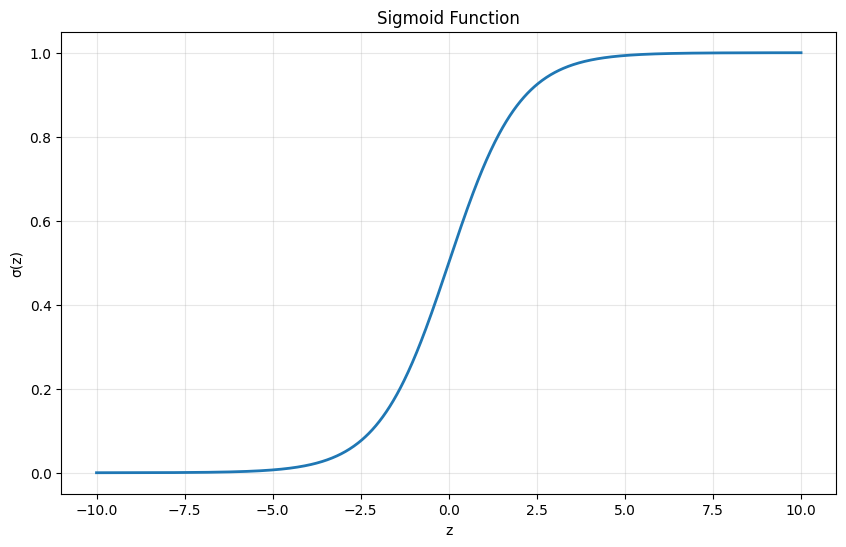

In [47]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 1000)
sigma_z = sigmoid(z)

plt.figure(figsize=(10, 6))
plt.plot(z, sigma_z, linewidth=2)
plt.xlabel('z')
plt.ylabel('σ(z)')
plt.title('Sigmoid Function')
plt.grid(True, alpha=0.3)
plt.show()

<span style="color:red">
It is easy to identify that the function goes between 0 and 1, the value when z=-10 is very close to 0, when z=10 is very close to 1 and when z=0, the value is 0.5
</span>

## Exercise 1
### Logistic regression

We will now introduce *classification* in a regression setting, reusing the same birth-weight data set as in the previous week.

### a)

- Fit a logistic regression model with `gender` as the response, using all the other covariates as predictors. You can use [`sm.Logit`](https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.Logit.html) from `statsmodels`.

- Print the model summary. Looking at the $p-values$ which variables do you consider to be relevant?

In [48]:
data = pd.read_csv('https://www.uio.no/studier/emner/matnat/math/STK1110/data/fodsler.txt', sep=r'\s+', engine='python')
data.rename(columns={'Kjonn': 'gender', 'SvDager': 'pregnancy_days', 'MorsAld': 'mother_age', 'Antfod': 'n_children', 'Fvekt': 'birth_weight'}, inplace=True)
data

,gender,pregnancy_days,mother_age,n_children,birth_weight
0,1,288,24,1,4070
1,1,286,27,0,4220
2,0,276,36,2,3690
3,1,265,31,0,3480
4,1,278,24,1,3970
...,...,...,...,...,...
995,0,273,25,0,3470
996,0,299,30,2,4010
997,1,267,25,3,4020
998,0,275,27,0,2910


In [ ]:
# Response: gender (0 = girl, 1 = boy)
y_logit = data['gender']
X_logit = sm.add_constant(data[['pregnancy_days', 'mother_age', 'n_children', 'birth_weight']])

logit_full = sm.Logit(y_logit, X_logit, missing="drop").fit()

print(logit_full.summary())

Optimization terminated successfully.
         Current function value: 0.677266
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                 gender   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      995
Method:                           MLE   Df Model:                            4
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                 0.01903
Time:                        01:27:17   Log-Likelihood:                -677.27
converged:                       True   LL-Null:                       -690.41
Covariance Type:            nonrobust   LLR p-value:                 2.778e-05
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.1328      1.590      0.713      0.476      -1.983       4.249
pregnancy_days   

<span style="color: red;">`birth_weight` might be the only relevant covariate. since is the only that has a p-value below 0.05</span>

### b)
Comment on the fit of your model. If you do not consider all covariates relevant, refit a smaller model with only the ones you want to keep, and compare the $AIC$.

In [ ]:
X_logit_small = sm.add_constant(data[['birth_weight']])

logit_small = sm.Logit(y_logit, X_logit_small, missing="drop").fit()

print(logit_small.summary())

print(f"Full model AIC:    {logit_full.aic:.2f}")
print(f"Reduced model AIC: {logit_small.aic:.2f}")

Optimization terminated successfully.
         Current function value: 0.679669
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                 gender   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      998
Method:                           MLE   Df Model:                            1
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                 0.01555
Time:                        01:27:17   Log-Likelihood:                -679.67
converged:                       True   LL-Null:                       -690.41
Covariance Type:            nonrobust   LLR p-value:                 3.585e-06
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.9384      0.462     -4.195      0.000      -2.844      -1.033
birth_weight     0.0006

<span style="color: red;">

Probably as expected, predicting baby gender from these covariates is not very meaningful: only ```birth_weight``` contributes much towards predicting `gender`. We therefore only include that as a covariate, and the AIC drops slightly.

</span>

### c)
The odds ratio and log-odds are two terms we make use of related to logistic regression.

- In your own words, define what they mean, and write down how they relate to a coefficient $\beta_j$ in a logistic regression model.

- For your final logistic regression model, program a way to report the estimates of these.

In [51]:
coef_table = pd.DataFrame({
    "log_odds (beta)": logit_small.params,
    "odds_ratio (exp(beta))": np.exp(logit_small.params),
})
print(coef_table)

              log_odds (beta)  odds_ratio (exp(beta))
const               -1.938390                0.143935
birth_weight         0.000592                1.000592


<span style="color: red;">

For a binary response with success probability $p$, the **odds**, **log-odds** and **odds ratio** are given by

$$
\text{odds} = \frac{p}{1-p}, \qquad
\text{log-odds} = \ln\!\left(\frac{p}{1-p}\right), \qquad
\text{odds ratio} = e^{\beta_j}.
$$

In logistic regression we model the log-odds as linear in the covariates,

$$
\ln\!\left(\frac{p_i}{1 - p_i}\right) = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip}.
$$

Each coefficient $\beta_j$ is the change in the log-odds per one-unit increase in $x_j$ (holding the others fixed), and $e^{\beta_j}$ is the corresponding odds ratio: the factor by which the odds of predicting a 1 are multiplied for that one-unit increase.

</span>

## Exercise 2

In this exercise we aim to predict the presence of a gene associated with the development of haemochromatosis (excess iron absorption during digestion). The variables in the Hemocromatosis.csv file are as follows:
- Gen: 0 – absence, 1 – presence

- Ferr: Serum ferritin level (µg/L)

- TSI: Transferrin saturation index (%)

- North: 0 – southern, 1 – northern

In [52]:
gen = pd.read_csv("Hemocromatosis.csv")
gen.tail()

,Gen,Ferr,TSI,North
75,1,860,58,1
76,1,1211,48,0
77,1,1014,67,1
78,1,888,58,0
79,1,691,86,0


### a)

Create a logistic regression model to explain the presence of the gene associated with haemochromatosis based on the other three variables in the database.

In [53]:
y_gen = gen['Gen']
X_gen = sm.add_constant(gen[['Ferr', "TSI", "North"]])

gen_model_full = sm.Logit(y_gen, X_gen, missing="drop").fit()
print(gen_model_full.summary())

Optimization terminated successfully.
         Current function value: 0.286370
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                    Gen   No. Observations:                   80
Model:                          Logit   Df Residuals:                       76
Method:                           MLE   Df Model:                            3
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                  0.5869
Time:                        01:27:17   Log-Likelihood:                -22.910
converged:                       True   LL-Null:                       -55.452
Covariance Type:            nonrobust   LLR p-value:                 4.812e-14
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -9.7236      2.137     -4.549      0.000     -13.913      -5.535
Ferr           0.0063      0.

### b)

- Calculate the odds ratio (OR, i.e. the odds multiplied by) if a person is from the north rather than from the south.
- Calculate the OR associated with a 100 µg/L difference in ferritin between two individuals.
- In each case, indicate which of the two hypothetical individuals is more likely to carry the gene in question.

In [ ]:
coef_north = gen_model_full.params['North']
coef_ferr = gen_model_full.params['Ferr']

or_north = np.exp(coef_north)
print(f"Odds Ratio (North vs South): {or_north:.4f}")
print(f"A person from the north is {or_north:.4f} times more likely to carry the gene.\n")

or_ferr_100 = np.exp(coef_ferr * 100)
print(f"Odds Ratio (100 µg/L increase in ferritin): {or_ferr_100:.4f}")
print(f"A person with 100 µg/L higher ferritin is {or_ferr_100:.4f} times more likely to carry the gene.")

Odds Ratio (North vs South): 6.4995
A person from the north is 6.4995 times more likely to carry the gene.

Odds Ratio (100 µg/L increase in ferritin): 1.8755
A person with 100 µg/L higher ferritin is 1.8755 times more likely to carry the gene.


When performing classification tasks, we use the confusion matrix to evaluate our model's predictive performance. In this matrix, the main diagonal contains the correct predictions, while the remaining cells represent the errors (misclassifications). By using the values from this matrix, we can calculate metrics such as specificity and sensitivity. Although these two metrics are related, they measure different aspects of the model and are calculated as follows:

Sensitivity (Recall)It measures the proportion of actual positives that were correctly identified:
$$\text{Sensitivity} = \frac{TP}{TP + FN}$$

SpecificityIt measures the proportion of actual negatives that were correctly identified:
$$\text{Specificity} = \frac{TN}{TN + FP}$$

### c)

Using the threshold of $0.5$, compute the confusion matrix, specificity, and sensitivity of the model using the provided data.

<span style="color:red">You can use the function `sklearn.metrics.confusion_matrix()`</span>

In [ ]:
y_pred_proba = gen_model_full.predict(X_gen)
y_pred = (y_pred_proba >= 0.5).astype(int)

cm = confusion_matrix(y_gen, y_pred)
print("Confusion Matrix:")
print(cm)
print()

TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f"True Negatives (TN):  {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP):  {TP}")
print()
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity:          {specificity:.4f}")

Confusion Matrix:
[[35  5]
 [ 6 34]]

True Negatives (TN):  35
False Positives (FP): 5
False Negatives (FN): 6
True Positives (TP):  34

Sensitivity (Recall): 0.8500
Specificity:          0.8750


### d)
Explain why we might prioritise Sensitivity and when Specificity.

<span style="color:red">

We might prioritize **Sensitivity** when missing a case is fatal, for example, in life-threatening scenarios as cancer screening), because we want to avoid having false negatives. We prefer (or we do not care too much) to have False Positives (FP) than having False Negatives (FN).

On the other side, we prioritize **Specificity** when the treatment or "false alarm" is invasive, e.g., confirming a diagnosis before performing risky surgery, or failing to flag an email as spam might be preferable to hiding relevant messages. When False Negatives do not cause a lot of damage, but a False Positive can be expensive.
</span>

The ROC curve allows us to visualise both metrics simultaneously, and shows how sensitivity changes as we sacrifice specificity. And the area under this curve can tell us how good the model is overall.

### e)
Computes and displays the ROC curve, calculates the area under the curve, and determines the cut-off point with the threshold of $p=0.5$ and the optimal point on the graph, which is the point closest to the top-left corner.

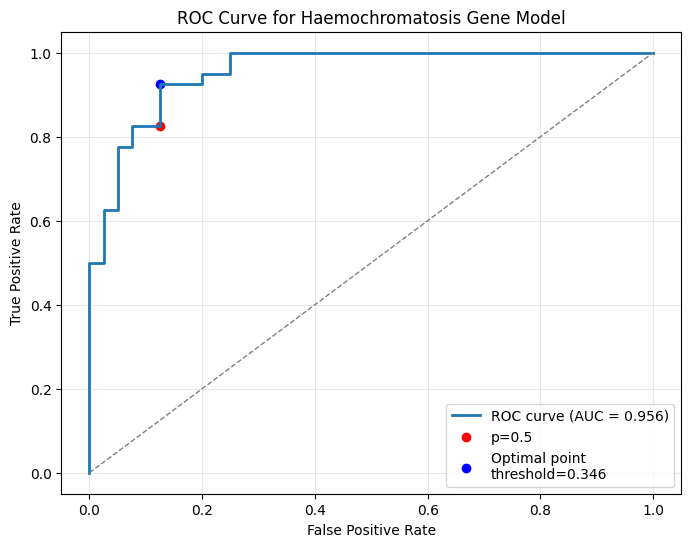

In [ ]:
fpr, tpr, thresholds = roc_curve(y_gen, y_pred_proba)
roc_auc = auc(fpr, tpr)

# p = 0.5
idx_0_5 = np.argmin(np.abs(thresholds - 0.5))
fpr_0_5, tpr_0_5, thr_0_5 = fpr[idx_0_5], tpr[idx_0_5], thresholds[idx_0_5]

# Optimal
dist = np.sqrt(fpr**2 + (1 - tpr)**2)
idx_opt = np.argmin(dist)
fpr_opt, tpr_opt, thr_opt = fpr[idx_opt], tpr[idx_opt], thresholds[idx_opt]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
plt.scatter([fpr_0_5], [tpr_0_5], color="red", label=f"p=0.5")
plt.scatter([fpr_opt], [tpr_opt], color="blue", label=f"Optimal point\nthreshold={thr_opt:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Haemochromatosis Gene Model")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### f)
What do you consider about the model? How far are the two points in the curve? Based on the area under the curve, is it a good model? Analyse your result.

<span style="color:red">

The Area Under the Curve (AUC) is 0.956, which is close to 1, this shows the model's good discriminative power. Values near 0.5 would indicate that the model performs no better than random chance.

The threshold generated by our model at $p=0.5$ is located very close to the optimal point on the ROC curve. This is a indicator of the model's robustness, showing that the default cutoff balances sensitivity and specificity.
</span>

## Exercise 3
### Cross Validation

Now that we already learnt how to create logistic models, in this section we will evaluate and compare them, for finally select the set of variables with best prediction capacity.

In this exercise we will use a dataset to predict if a person sufferd from a stroke based on many other variables. The dataset is loaded and irrelevant columns are dropped. As you can see, there are both continuous and categorical values.

In [57]:
stroke = pd.read_csv("healthcare-dataset-stroke-data.csv")
stroke.drop(columns=['bmi', "id", "hypertension", "heart_disease"], inplace=True)
stroke

,gender,age,ever_married,work_type,Residence_type,avg_glucose_level,smoking_status,stroke
0,Male,67.0,Yes,Private,Urban,228.69,formerly smoked,1
1,Female,61.0,Yes,Self-employed,Rural,202.21,never smoked,1
2,Male,80.0,Yes,Private,Rural,105.92,never smoked,1
3,Female,49.0,Yes,Private,Urban,171.23,smokes,1
4,Female,79.0,Yes,Self-employed,Rural,174.12,never smoked,1
...,...,...,...,...,...,...,...,...
5105,Female,80.0,Yes,Private,Urban,83.75,never smoked,0
5106,Female,81.0,Yes,Self-employed,Urban,125.20,never smoked,0
5107,Female,35.0,Yes,Self-employed,Rural,82.99,never smoked,0
5108,Male,51.0,Yes,Private,Rural,166.29,formerly smoked,0


### a)
We will start by a little bit of data visualization. Start by ploting the counts of each value of column `stroke`. If we had a model that always predicts category $0$, what would be the accuracy of that model? Why might this happen?

4.87% of observations have stroke have the value 1


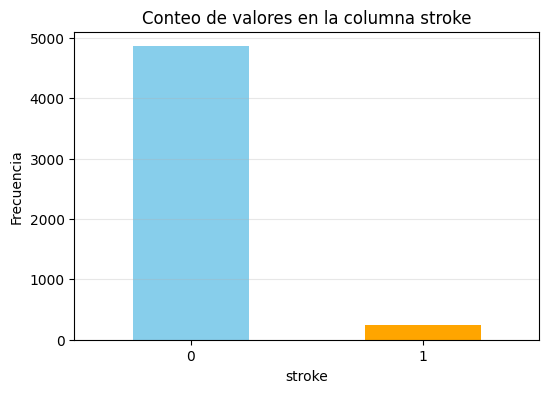

In [ ]:
counts = stroke['stroke'].value_counts().sort_index()
print(f"{stroke['stroke'].mean() * 100:.2f}% of observations have stroke have the value 1")

plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color=['skyblue', 'orange'])
plt.xlabel('stroke')
plt.ylabel('Frequency')
plt.title('Counts')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

<span style="color:red">

Less than $5\%$ of the observations are classified as $1$, that means that our classes are very **imbalanced**. If we had a model that only predicts $0$ for every sample, its accuracy would be more than $95\%$ (it would be $95.13\%$). This is why we will give importance to sensitivity and specificity.
</span>

### b)
Create a logistic regression model with all the variables of the dataset. You should use `pd.get_dummies()` and convert the variables to float with `.astype(float)` to correctly preprocess the categorical variables.

Once you create the dummy variables, add the constant and create the model you will see that the model is composed by many variables, many of them with very low p-values associated. What are these variables?

In [59]:
y_stroke = stroke['stroke']
X_stroke = stroke.drop(columns='stroke')
X_stroke = pd.get_dummies(X_stroke, drop_first=True)
X_stroke = sm.add_constant(X_stroke)

X_stroke = X_stroke.astype(float)
y_stroke = y_stroke.astype(float)

stroke_logit = sm.Logit(y_stroke, X_stroke, missing="drop").fit()
print(stroke_logit.summary())

         Current function value: 0.155499
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                 stroke   No. Observations:                 5110
Model:                          Logit   Df Residuals:                     5096
Method:                           MLE   Df Model:                           13
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                  0.2016
Time:                        01:27:18   Log-Likelihood:                -794.60
converged:                      False   LL-Null:                       -995.19
Covariance Type:            nonrobust   LLR p-value:                 1.264e-77
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -7.9550      0.469    -16.960      0.000      -8.874      -7.036
age  

c:\Users\jpeir\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<span style="color:red">
When we create dummy variables, we are creating one variable for each class; this is the reason why we suddenly have so many variables. In practice, it often happens that some categories have a significant p-value while others do not. Nevertheless, it is not good practice to remove categories individually; instead, you should remove the entire chunk of categories associated with that variable.
</span>

### c)
Create now a model as before but only with the continuous variables, i.e. `age` and `avg_glucose_level`.

In [60]:
X_stroke_red = sm.add_constant(stroke[['age', "avg_glucose_level"]])

stroke_logit_red = sm.Logit(y_stroke, X_stroke_red, missing="drop").fit()
print(stroke_logit_red.summary())

Optimization terminated successfully.
         Current function value: 0.156537
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                 stroke   No. Observations:                 5110
Model:                          Logit   Df Residuals:                     5107
Method:                           MLE   Df Model:                            2
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                  0.1962
Time:                        01:27:18   Log-Likelihood:                -799.90
converged:                       True   LL-Null:                       -995.19
Covariance Type:            nonrobust   LLR p-value:                 1.548e-85
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -7.6478      0.354    -21.588      0.000      -8.342      -6.953
age     

The cross-validation method is used to validate different models, select variables and assess predictive ability. It involves first taking the dataset and dividing it into several folds – let’s say 10, for example – and in each iteration using 9 of the folds to estimate the parameters, whilst using the last fold to validate the model’s predictive ability on a dataset not seen during training.

### d)
Create a function that takes the next parameters as input:
- X: The covariates matrix
- y: The target variable
- n_splits: The number of folds
- threshold: The value that we will use to asses if the prediction is 1 or 0

And the function must perform cross-validation; in each iteration, it must calculate the accuracy, sensitivity and specificity of the validation fold, and it must return the result of each iteration as well as the average of all the results.

You can use the function `sklearn.model_selection.StratifiedKFold()` to divide the data.

In [61]:
def cv_logit_assessment(X, y, n_splits=10, threshold=0.5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=12345)
    records = []
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = sm.Logit(y_train, X_train, missing="drop").fit(disp = 0)
        proba = model.predict(X_test)
        y_pred = (proba >= threshold).astype(int)

        cm = confusion_matrix(y_test.astype(int), y_pred)
        TN, FP, FN, TP = cm.ravel()

        records.append({
            "fold": fold,
            "accuracy": accuracy_score(y_test, y_pred),
            "sensitivity": TP / (TP + FN) if TP + FN else np.nan,
            "specificity": TN / (TN + FP) if TN + FP else np.nan,
        })

    result_df = pd.DataFrame(records).set_index("fold")
    return result_df, result_df.mean()

### e)
Now, apply this function to:
- The set of only continuous variables
- The continuous variables with `Residence_type` and `smoking_status`

What is the sensitivity and specificity when the threshold is $0.5$?

Now do the same but with other values of the threshold. Do you see any change? Why is that happening?

Do these categorical variables we are adding improve or worsen the outcome?

In [62]:
cv_full_cont, cv_full_mean_cont = cv_logit_assessment(X_stroke_red, y_stroke)
print("Only continuous:\n",cv_full_mean_cont)


X_stroke_dummy = pd.get_dummies(stroke[['age', "avg_glucose_level", "Residence_type", "smoking_status"]], drop_first=True)
X_stroke_dummy_const = sm.add_constant(X_stroke_dummy).astype(float)

cv_full_dummy, cv_full_mean_dummy = cv_logit_assessment(X_stroke_dummy_const, y_stroke)
print("\nWith dummy variables:\n", cv_full_mean_dummy)

Only continuous:
 accuracy       0.951272
sensitivity    0.000000
specificity    1.000000
dtype: float64

With dummy variables:
 accuracy       0.951272
sensitivity    0.000000
specificity    1.000000
dtype: float64


In [63]:
cv_full_cont, cv_full_mean_cont = cv_logit_assessment(X_stroke_red, y_stroke, threshold=0.2)
print("Only continuous:\n",cv_full_mean_cont)


X_stroke_dummy = pd.get_dummies(stroke[['age', "avg_glucose_level", "Residence_type", "smoking_status"]], drop_first=True)
X_stroke_dummy_const = sm.add_constant(X_stroke_dummy).astype(float)

cv_full_dummy, cv_full_mean_dummy = cv_logit_assessment(X_stroke_dummy_const, y_stroke, threshold=0.2)
print("\nWith dummy variables:\n", cv_full_mean_dummy)

Only continuous:
 accuracy       0.924462
sensitivity    0.196167
specificity    0.961738
dtype: float64

With dummy variables:
 accuracy       0.921722
sensitivity    0.180333
specificity    0.959679
dtype: float64


<span style="color:red">

When the threshold in both cases is $0.5$, the models predict all observations as class $0$; so although the accuracy is high and the specificity is perfect, the model’s overall performance is very poor, especially in a case like this where sensitivity is particularly important and the model produces disastrous results.

However, by changing the threshold value to, for example, $0.2$, the result improves; we can now see that not all observations are predicted as $1$, and the sensitivity value is no longer $0$.

In general, adding dummy variables does not improve the performance of the model, so we can consider removing them.
</span>